In [1]:
!pip install networkx tqdm python-louvain matplotlib pandas numpy scipy scikit-learn


## Завантаження даних та імпорт бібліотек

In [3]:
import os
import urllib.request
import gzip
import shutil
import itertools
from tqdm import tqdm
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from networkx.algorithms import community as nx_comm

# Для порівняння спільнот:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score


In [4]:
# Шляхи/URL
TOP5000_URL = "https://snap.stanford.edu/data/bigdata/communities/com-friendster.top5000.cmty.txt.gz"
ALL_CMTY_URL = "https://snap.stanford.edu/data/bigdata/communities/com-friendster.all.cmty.txt.gz"
UNGRAPH_URL = "https://snap.stanford.edu/data/bigdata/communities/com-friendster.ungraph.txt.gz"

TOP5000_GZ = "com-friendster.top5000.cmty.txt.gz"
TOP5000_TXT = "com-friendster.top5000.cmty.txt"
UNGRAPH_GZ = "com-friendster.ungraph.txt.gz"   # large — DO NOT download unless you know limits
SAMPLE_UNGRAPH = "friendster-ungraph-sample.gz"  # local sample if we fetch part


In [5]:
if not os.path.exists(TOP5000_TXT):
    if not os.path.exists(TOP5000_GZ):
        urllib.request.urlretrieve(TOP5000_URL, TOP5000_GZ)
    with gzip.open(TOP5000_GZ, "rb") as f_in:
        with open(TOP5000_TXT, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)


## Зчитати спільноти, базова статистика і перекриття, тільки top5000

Зчитано спільнот: 5000
Розмір спільнот — min, mean, median, max: 3 46.8064 33.0 1612
Унікальних вузлів у top5000: 220015
Вузлів, що входять у >1 спільнот: 12691 ( 5.768243074335841 % )


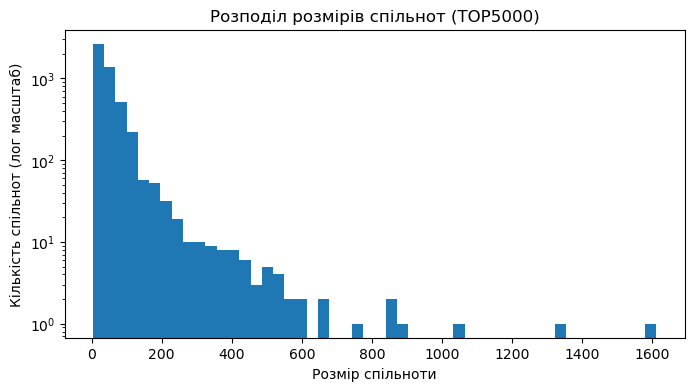

In [7]:
communities = []
with open(TOP5000_TXT, "r") as f:
    for line in f:
        nodes = line.strip().split()
        if len(nodes) >= 3:  # за умовою видаляємо спільноти з <3 вузлів
            communities.append(nodes)
len_communities = len(communities)
print(f"Зчитано спільнот: {len_communities}")

sizes = np.array([len(c) for c in communities])
print("Розмір спільнот — min, mean, median, max:", sizes.min(), sizes.mean(), np.median(sizes), sizes.max())

# Унікальні вузли і ступінь перекриття
all_nodes = [n for c in communities for n in c]
unique_nodes = set(all_nodes)
print("Унікальних вузлів у top5000:", len(unique_nodes))

counter = Counter(all_nodes)
multi_members = sum(1 for v in counter.values() if v > 1)
print("Вузлів, що входять у >1 спільнот:", multi_members, "(", 100*multi_members/len(unique_nodes), "% )")

# Гістограма розмірів
plt.figure(figsize=(8,4))
plt.hist(sizes, bins=50, log=True)
plt.xlabel("Розмір спільноти")
plt.ylabel("Кількість спільнот (лог масштаб)")
plt.title("Розподіл розмірів спільнот (TOP5000)")
plt.show()


## Побудова індукованого підграфа — безпечний підхід (стрімінг з ungraph, додавання тільки ребер між nodeset)

In [9]:
if not os.path.exists(SAMPLE_UNGRAPH):
    print("Завантаження")
    try:
        req = urllib.request.urlopen(UNGRAPH_URL)
        with open(SAMPLE_UNGRAPH, "wb") as f:
            f.write(req.read(50_000_000))  # 50 MB
        print("Завантажено", SAMPLE_UNGRAPH)
    except Exception as e:
        print("Не вдалося завантажити sample:", e)


## будуємо індукований підграф (тільки ребра між nodeset)

In [11]:
import itertools

nodeset = set(unique_nodes)
G = nx.Graph()
G.add_nodes_from(nodeset)
sample_ok = os.path.exists(SAMPLE_UNGRAPH)

if sample_ok:
    added = 0
    with gzip.open(SAMPLE_UNGRAPH, "rt", errors="ignore") as f:
        try:
            for line in tqdm(itertools.islice(f, 0, None), desc="Парсим sample"):
                if line.startswith("#") or not line.strip():
                    continue
                try:
                    u, v = line.split()
                except ValueError:
                    # на випадок пошкодженого рядка
                    continue
                if u in nodeset and v in nodeset:
                    G.add_edge(u, v)
                    added += 1
        except EOFError:
            print("\n Помилка")

    print(f"Граф: {G.number_of_nodes()} вузлів, {G.number_of_edges()} ребер (додано {added})")


Парсим sample: 10431845it [00:36, 284564.64it/s]



 Помилка
Граф: 220015 вузлів, 37587 ребер (додано 37587)


## Fallback: якщо немає ребер із real ungraph — збудувати демонстраційний граф

In [13]:
# Якщо G не має ребер (або має дуже мало), створимо demo-граф із подібними n
if G.number_of_edges() == 0:
    print("G має 0 ребер — створюємо демо-граф (Barabasi-Albert) з N = number of unique nodes (обережно: зменшуємо розмір для пам'яті).")
    N = min(20000, len(unique_nodes))  # зменшуємо для нормальної роботи
    m_param = 3
    print("BA граф N=", N, "m=", m_param)
    G = nx.barabasi_albert_graph(N, m_param, seed=42)
    print("Вузлів:", G.number_of_nodes(), "Ребер:", G.number_of_edges())

## Перевірка: базові метрики графа

In [15]:
n = G.number_of_nodes()
m = G.number_of_edges()
deg_seq = np.array([d for _, d in G.degree()])
print("n, m:", n, m)
print("avg degree:", deg_seq.mean())
print("min, max degree:", deg_seq.min(), deg_seq.max())
print("density:", nx.density(G))

try:
    avg_clust = nx.average_clustering(G)
    print("avg clustering:", avg_clust)
except Exception as e:
    print("Не вдалося порахувати average_clustering:", e)

print("number of connected components:", nx.number_connected_components(G))


n, m: 220015 37587
avg degree: 0.3416767038611004
min, max degree: 0 277
density: 1.5529771008258583e-06
avg clustering: 0.008569197580778622
number of connected components: 209500


## Degree distribution — PDF + CDF (коректно фільтруємо нулі)

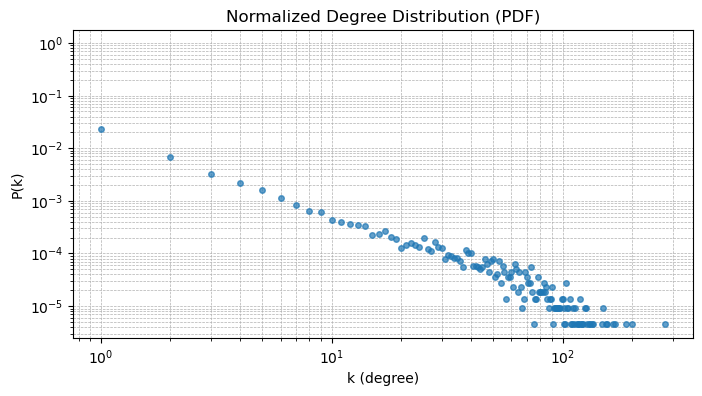

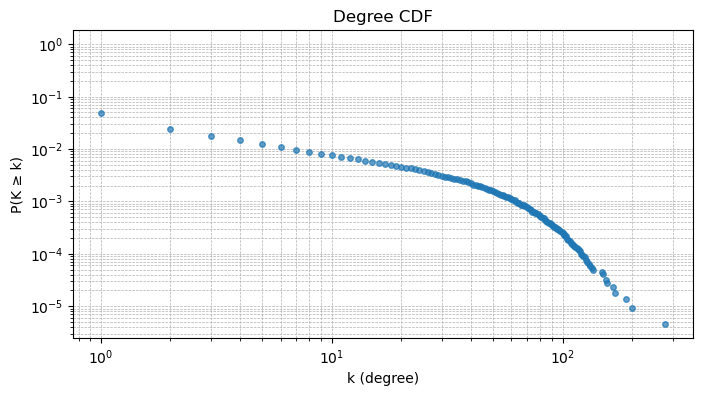

In [17]:
deg_seq = np.array([d for _, d in G.degree()])
deg_hist = np.bincount(deg_seq)
degrees = np.arange(len(deg_hist))
counts = deg_hist
mask = counts > 0
degrees = degrees[mask]
counts = counts[mask]

# PDF
prob = counts / counts.sum()
plt.figure(figsize=(8,4))
plt.loglog(degrees, prob, 'o', markersize=4, alpha=0.7)
plt.xlabel("k (degree)")
plt.ylabel("P(k)")
plt.title("Normalized Degree Distribution (PDF)")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()

# CDF (P(K >= k))
cdf = np.cumsum(prob[::-1])[::-1]
plt.figure(figsize=(8,4))
plt.loglog(degrees, cdf, 'o', markersize=4, alpha=0.7)
plt.xlabel("k (degree)")
plt.ylabel("P(K ≥ k)")
plt.title("Degree CDF")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()


## Центральності (мера попередження про масштаб)

In [19]:
# Degree centrality (швидко)
deg_cent = nx.degree_centrality(G)

# PageRank
pr = nx.pagerank(G, max_iter=200)

# Betweenness
try:
    bet = nx.betweenness_centrality(G, k=min(200, max(10, int(np.sqrt(n)))), seed=42)  # вибір k залежить від розміру
except Exception as e:
    bet = {}
    print("Betweenness не пораховано через розмір:", e)

# Вивід топ-5 вузлів за PageRank
top_pr = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top PageRank (top10):", top_pr)


Top PageRank (top10): [('244312', 0.0007798842946113362), ('370061', 0.0004278281592423856), ('383056', 0.00039351479463581047), ('413339', 0.00035317948897493553), ('198774', 0.0003488436455602375), ('469169', 0.00031642687680665557), ('396482', 0.00031459524169207367), ('590347', 0.0003049682975700674), ('417254', 0.00030280511788409415), ('698547', 0.00029776126986363086)]


## Виявлення спільнот та порівняння з ground-truth

In [21]:
node_to_gt = {}
if 'unique_nodes' in globals() and len(unique_nodes) > 0:
    # для кожної ground-truth спільноти у top5000 присвоїмо id (перший знайдений)
    for idx, comm in enumerate(communities):
        for v in comm:
            if v in G:  # якщо G використовує той же ID тип — може не співпасти у demo fallback
                node_to_gt[v] = idx

# Якщо G є демо (integer nodes), пропустимо порівняння
if len(node_to_gt) == 0:
    print("Ground-truth labels недоступні для цього G (demo або відсутність збігів). Пропускаємо порівняння.")
else:
    # створюємо список вузлів, їхні GT лейбли (ціль: скаляр для sklearn)
    nodes_in_G = [n for n in G.nodes() if n in node_to_gt]
    gt_labels = [node_to_gt[n] for n in nodes_in_G]
    print("Готові GT мітки для", len(nodes_in_G), "вузлів")


Готові GT мітки для 220015 вузлів


In [22]:
# Використаємо greedy_modularity_communities (NetworkX) — підходить для невеликих/середніх графів
communities_pred = list(nx_comm.greedy_modularity_communities(G))
print("Кількість знайдених спільнот (greedy):", len(communities_pred))

# Якщо є GT labels і співпадаючі вузли — підрахуємо NMI/ARI
if len(node_to_gt) > 0:
    # створюємо predicted labels для nodes_in_G
    pred_map = {}
    for cid, comm in enumerate(communities_pred):
        for v in comm:
            if v in node_to_gt:
                pred_map[v] = cid
    pred_labels = [pred_map.get(n, -1) for n in nodes_in_G]  # -1 для невизначених
    # Фільтруємо ті вузли, де pred != -1
    valid_idx = [i for i, lbl in enumerate(pred_labels) if lbl != -1]
    if len(valid_idx) > 0:
        gt_sub = [gt_labels[i] for i in valid_idx]
        pred_sub = [pred_labels[i] for i in valid_idx]
        nmi = normalized_mutual_info_score(gt_sub, pred_sub)
        ari = adjusted_rand_score(gt_sub, pred_sub)
        print("NMI:", nmi, "ARI:", ari)
    else:
        print("Не знайдено співпадаючих вузлів між GT і predicted communities.")


Кількість знайдених спільнот (greedy): 209535
NMI: 0.7795305797800762 ARI: 0.017275478299165953


## Збереження результатів і графіків

In [24]:
pd.DataFrame({'community_size': sizes}).to_csv("top5000_community_sizes.csv", index=False)
pd.DataFrame(list(pr.items()), columns=["node", "pagerank"]).sort_values("pagerank", ascending=False).head(200).to_csv("pagerank_top200.csv", index=False)

print("Збережено CSV результати")


Збережено CSV результати


# РЕЗУЛЬТАТИ В ФАЙЛІ Results.ipynb